# 02 HEST-1k SF 诊断与下一步模型修改

这个 notebook 记录当前 HIPT MLP size factor predictor 的失败原因诊断。重点不是重新训练，而是把已经跑完的诊断结果整理清楚：模型在哪些器官、哪些队列、哪些切片上有效，在哪些地方失败，以及下一步为什么要改模型。

当前诊断目录：`../results/hest1k_human_visium_sf/diagnostics/sf_main_hipt256_leave_slide_out/`。

## 1. 诊断问题

当前模型已经证明 H&E 图像特征里有 SF 信号，但它还不能作为主结论模型。核心问题有三个：

1. **整体相关性中等**：test `log_sf_pearson` 约为 `0.52`，说明能排出一部分高低趋势，但还不够强。
2. **预测波动偏小**：test `sf_std_ratio` 约为 `0.40`，说明模型预测的 SF 起伏只有真实起伏的 40% 左右。
3. **高 SF 区域低估**：test `sf_top_decile_mean_ratio` 约为 `0.58`，说明真实最高 10% 区域里，模型平均只预测到真实强度的 58% 左右。

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

DIAG = Path("../results/hest1k_human_visium_sf/diagnostics/sf_main_hipt256_leave_slide_out")
assert DIAG.exists(), DIAG

overall = pd.read_csv(DIAG / "metrics_overall_uncalibrated.csv")
overall_cal = pd.read_csv(DIAG / "metrics_overall_val_affine_calibrated.csv")
by_slide = pd.read_csv(DIAG / "metrics_by_slide_uncalibrated.csv")
by_organ = pd.read_csv(DIAG / "metrics_by_organ_uncalibrated.csv")
calibration = pd.read_json(DIAG / "calibration.json", typ="series")

metric_cols = [
    "log_sf_pearson",
    "sf_pearson",
    "log_sf_mae",
    "log_sf_rmse",
    "sf_std_ratio",
    "sf_top_decile_mean_ratio",
    "log_sf_top_decile_mae",
    "n_spots",
]

display(overall[["split"] + metric_cols].round(4))
display(Markdown(f"验证集 affine calibration: `scale={calibration['scale']:.4f}`, `bias={calibration['bias']:.4f}`"))
display(overall_cal[["split"] + metric_cols].round(4))

,split,log_sf_pearson,sf_pearson,log_sf_mae,log_sf_rmse,sf_std_ratio,sf_top_decile_mean_ratio,log_sf_top_decile_mae,n_spots
0,test,0.5231,0.3074,0.6606,1.0640,0.4039,0.5772,0.6890,213402
1,train,0.6738,0.4626,0.5421,0.9769,0.4666,0.6919,0.4637,649416
2,val,0.5080,0.5457,0.6219,0.9895,0.7876,0.5737,0.7423,78046


验证集 affine calibration: `scale=0.6606`, `bias=-0.2335`

,split,log_sf_pearson,sf_pearson,log_sf_mae,log_sf_rmse,sf_std_ratio,sf_top_decile_mean_ratio,log_sf_top_decile_mae,n_spots
0,test,0.5207,0.3076,0.6671,1.0665,0.2689,0.4893,0.7143,213402
1,train,0.6743,0.4523,0.5998,1.0438,0.3186,0.5694,0.5472,649416
2,val,0.4919,0.5574,0.6125,0.9859,0.5404,0.5026,0.7484,78046


## 2. 全局校准没有解决问题

验证集 affine calibration 指的是只拟合一个线性校准：`pred_calibrated = a * pred + b`。如果模型只是整体偏大或偏小，这一步应该能改善 test 结果。

但这次校准后的 test 表现变差：

| 设置 | test log SF 相关性 | test log SF MAE | SF 波动恢复比例 | 最高 10% SF 强度恢复比例 |
|---|---:|---:|---:|---:|
| 未校准 | 0.5231 | 0.6606 | 0.4039 | 0.5772 |
| validation affine calibration | 0.5207 | 0.6671 | 0.2689 | 0.4893 |

结论：问题不是一个简单的全局尺度偏差。模型在不同器官、不同队列上学到的规律不一致，因此只靠 `a, b` 校准会把某些切片进一步压平。

In [2]:
test_organs = by_organ[by_organ["split"] == "test"].copy()
organ_view = test_organs.sort_values("log_sf_pearson")[[
    "organ",
    "log_sf_pearson",
    "log_sf_mae",
    "sf_std_ratio",
    "sf_top_decile_mean_ratio",
    "n_spots",
]]
display(organ_view.round(4))

,organ,log_sf_pearson,log_sf_mae,sf_std_ratio,sf_top_decile_mean_ratio,n_spots
4,Cervix,-0.0091,1.5455,0.1042,0.2079,472
12,Pancreas,-0.0043,2.0029,0.1676,0.1497,3320
8,Liver,0.0101,2.6476,0.0334,0.1304,5489
0,Bladder,0.1782,0.4622,0.9330,0.5578,976
10,Lymph node,0.2053,0.7139,0.7017,0.6081,4886
7,Kidney,0.2149,0.4833,0.6715,0.5104,33239
13,Prostate,0.3856,0.6883,0.7199,0.5372,20983
9,Lung,0.4132,0.8352,0.7124,0.4870,15514
2,Brain,0.4667,0.4382,0.5245,0.5713,32674
11,Ovary,0.5043,0.4305,0.6355,0.6121,3449


## 3. 失败主要集中在特定器官

test set 的器官级结果显示：

- **表现较好**：Breast、Bowel、Skin、Eye、Heart。
- **明显失败**：Liver、Pancreas、Cervix。
- **中间状态**：Kidney、Lung、Prostate、Brain、Ovary、Uterus。

这说明 H&E 到 SF 的映射不是一个完全统一的单一规律。不同器官的组织结构、测序平台版本、样本制备方式和图像质量会改变目标分布。后续模型修改必须把切片内空间上下文和队列级差异纳入诊断，而不是只看一个总体 test 相关性。

In [3]:
test_slides = by_slide[by_slide["split"] == "test"].copy()

worst_slides = test_slides.sort_values("log_sf_pearson").head(12)[[
    "sample_id",
    "organ",
    "cohort",
    "log_sf_pearson",
    "log_sf_mae",
    "sf_std_ratio",
    "sf_top_decile_mean_ratio",
    "n_spots",
]]

best_slides = test_slides.sort_values("log_sf_pearson", ascending=False).head(8)[[
    "sample_id",
    "organ",
    "cohort",
    "log_sf_pearson",
    "log_sf_mae",
    "sf_std_ratio",
    "sf_top_decile_mean_ratio",
    "n_spots",
]]

display(Markdown("### 最差 test slides"))
display(worst_slides.round(4))
display(Markdown("### 最好 test slides"))
display(best_slides.round(4))

### 最差 test slides

,sample_id,organ,cohort,log_sf_pearson,log_sf_mae,sf_std_ratio,sf_top_decile_mean_ratio,n_spots
17,MEND66,Brain,Spatially resolved transcriptomic profiling of...,-0.1689,1.0115,0.2787,0.1485,1201
43,MISC66,Bowel,COLON MAP: Colon Molecular Atlas Project,-0.0290,0.8935,0.5063,0.3388,3946
46,NCBI3,Cervix,Spatiotemporally Deciphering the Unknown Role ...,-0.0091,1.5455,0.1042,0.2079,472
76,NCBI833,Liver,Multimodal decoding of human liver regeneratio...,-0.0051,2.6771,0.0359,0.1372,1759
61,NCBI572,Pancreas,Schwann Cells Shape Tumor Cells and Cancer-Ass...,-0.0043,2.0029,0.1676,0.1497,3320
84,ZEN43,Bowel,Charting the Heterogeneity of Colorectal Cance...,0.0008,0.2786,0.6422,0.6506,691
68,NCBI672,Liver,Single-cell and spatial transcriptomics charac...,0.0112,2.6952,0.1128,0.1293,1421
75,NCBI826,Liver,Multimodal decoding of human liver regeneratio...,0.0152,2.5957,0.0148,0.1247,2309
7,INT7,Kidney,Tertiary lymphoid structures generate and prop...,0.0447,0.4836,0.5819,0.5058,2361
0,INT1,Kidney,Tertiary lymphoid structures generate and prop...,0.0836,0.5687,1.0303,0.5528,1032


### 最好 test slides

,sample_id,organ,cohort,log_sf_pearson,log_sf_mae,sf_std_ratio,sf_top_decile_mean_ratio,n_spots
83,TENX91,Bowel,Visium CytAssist Gene Expression Libraries of ...,0.9275,0.4933,1.0256,0.9467,5943
77,TENX23,Breast,"Human Breast Cancer: Targeted, Immunology Panel",0.8980,0.4470,0.8521,0.7651,4321
56,NCBI509,Skin,Spatial transcriptomics landscape of non-commu...,0.8839,0.8143,0.8594,0.8978,760
82,TENX90,Bowel,Visium CytAssist Gene Expression Libraries of ...,0.8737,0.6095,1.0520,0.8612,6042
49,NCBI473,Skin,Spatial transcriptomics landscape of non-commu...,0.8310,1.6890,1.1338,1.0991,733
25,MISC119,Heart,Spatially resolved multiomics of human cardiac...,0.8197,0.4116,0.7237,0.6597,3400
52,NCBI489,Skin,Spatial transcriptomics landscape of non-commu...,0.8181,0.7283,0.9041,0.8780,584
12,MEND35,Bowel,"Human ileum, Visium",0.8112,0.5181,0.7994,0.7075,3273


## 4. 空间叠图诊断

每张空间诊断图包含四列：

1. `true log SF`：真实的 log size factor 空间分布。
2. `pred log SF`：模型预测的 log size factor 空间分布。
3. `calibrated pred log SF`：验证集 affine calibration 后的预测。
4. `residual pred - true`：预测减真实，红蓝越明显代表误差越大。

下面放两个代表：`TENX91` 是成功案例，`NCBI833` 是失败案例。

### TENX91

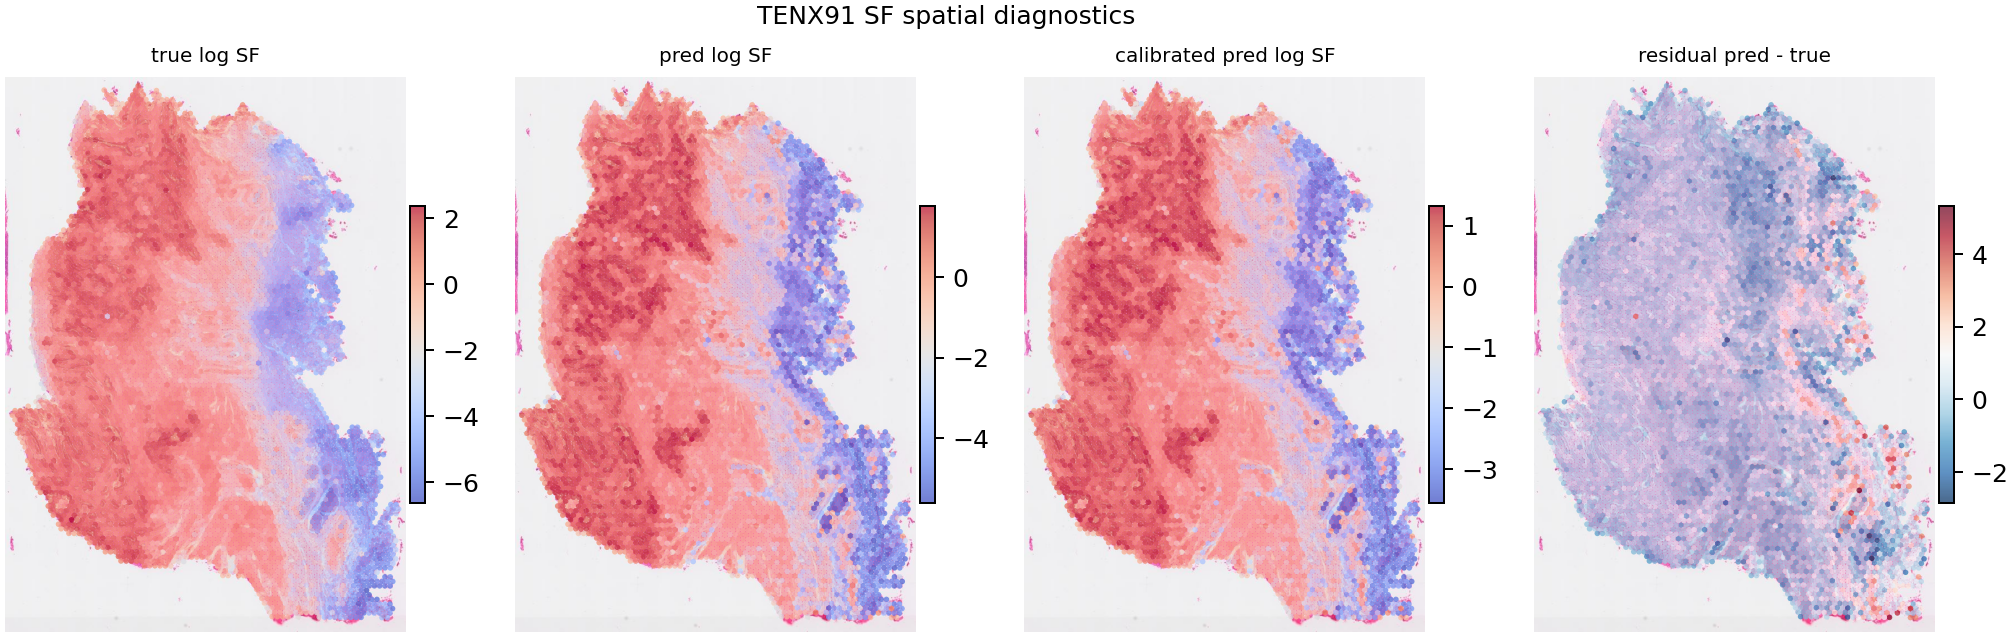

### NCBI833

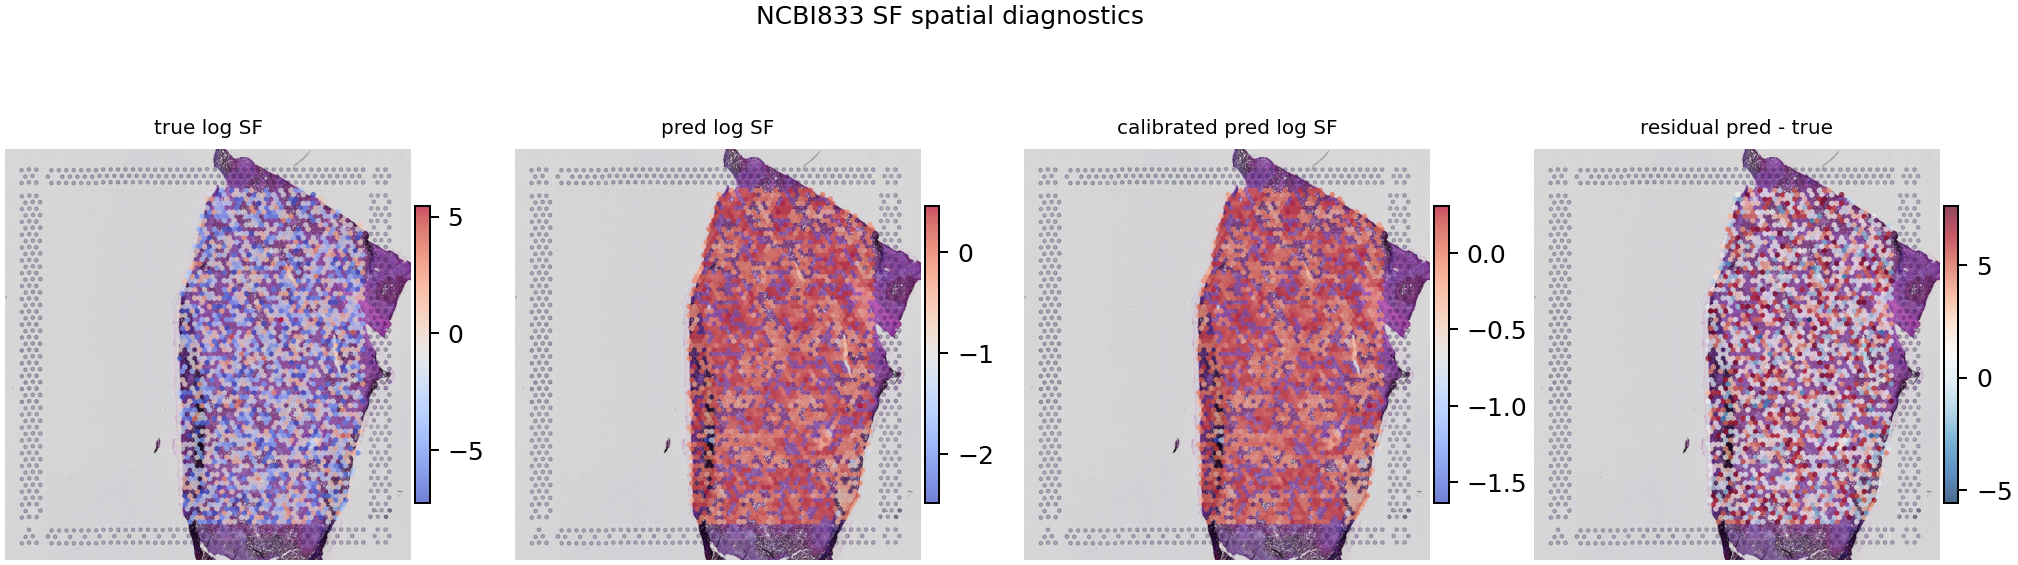

In [4]:
for slide_id in ["TENX91", "NCBI833"]:
    image_path = DIAG / "plots" / "spatial" / f"{slide_id}_sf_spatial_diagnostics.png"
    display(Markdown(f"### {slide_id}"))
    display(Image(filename=str(image_path)))

## 5. 当前判断

当前模型的问题不是“完全没信号”，而是“有信号但不稳”。成功切片说明 HIPT patch 特征能捕捉到一部分组织区域的测序强度变化；失败切片说明单个 spot patch 的局部图像特征不够，尤其不能恢复某些器官里强烈的 SF 尾部区域。

所以下一步模型修改不应该只是调学习率或加深 MLP，而应该先补两类信息：

1. **空间上下文特征**：每个 spot 不只看自己的 HIPT patch，还看附近 spot 的 HIPT 均值、差异和空间邻域结构。
2. **切片内分布约束**：训练时显式惩罚预测被压平，尤其惩罚真实高 SF 区域的系统性低估。

这两个修改对应当前最大错误：`sf_std_ratio` 太低、`sf_top_decile_mean_ratio` 太低。

## 6. 下一步实验

下一步不覆盖现有 `features.npy`，而是创建新的上下文特征文件和新的 manifest/config，保证原始 HIPT 结果可以复现。

计划如下：

1. 为每张 slide 生成 `features_context.npy`：拼接原始 HIPT feature、空间邻居均值、当前 spot 与邻居均值的差、邻域方差，以及归一化坐标。
2. 生成 `human_visium_sf_manifest_context.csv`：只把 `features_path` 指向新的上下文特征，其他 counts、coords、size factor 保持不变。
3. 训练 context SF predictor：使用同一个 leave-slide-out split，不能随机 spot split。
4. 用同一套 diagnostics 脚本比较：重点看 test `log_sf_pearson`、`sf_std_ratio`、`sf_top_decile_mean_ratio` 是否改善。
5. 如果 context 模型改善，再继续做 leave-cohort-out 和 leave-organ-out；如果没有改善，继续检查失败器官的 target 分布和数据质量。

## 7. 已完成的模型修改与结果

本轮已经完成三类模型修改：

1. `context`：加入空间邻域 HIPT 均值和坐标/密度特征。
2. `context_slide_balanced`：在 context 特征基础上使用 slide-balanced sampling。
3. `context_distribution` / `context_distribution_light`：在 context 特征基础上加入分布宽度约束，避免预测过度压平。

test set 结果如下：

| 模型 | log SF 相关性 | log SF MAE | SF 波动恢复比例 | 最高 10% SF 强度恢复比例 | 判断 |
|---|---:|---:|---:|---:|---|
| 原始 HIPT MLP | 0.5231 | 0.6606 | 0.4039 | 0.5772 | 有信号，但不够 |
| context | 0.5864 | 0.6080 | 0.4072 | 0.6108 | 平均误差最好 |
| context + slide-balanced | 0.5434 | 0.6572 | 0.4044 | 0.5753 | 不采用 |
| context + distribution | 0.5809 | 0.6371 | 0.4486 | 0.6374 | 尾部恢复最好 |
| context + light distribution | 0.5878 | 0.6212 | 0.4154 | 0.6172 | 当前综合候选 |

结论：空间 context 是有效修改；slide-balanced sampling 没有帮助；分布约束能改善尾部和波动，但权重要轻。当前可以把 `context + light distribution` 作为下一轮候选模型，同时保留普通 `context` 作为平均误差更低的对照。

In [5]:
experiment_dirs = {
    "main_hipt_mlp": DIAG,
    "context": Path("../results/hest1k_human_visium_sf/diagnostics/sf_context_hipt256_leave_slide_out"),
    "context_slide_balanced": Path("../results/hest1k_human_visium_sf/diagnostics/sf_context_slide_balanced_hipt256_leave_slide_out"),
    "context_distribution": Path("../results/hest1k_human_visium_sf/diagnostics/sf_context_distribution_hipt256_leave_slide_out"),
    "context_distribution_light": Path("../results/hest1k_human_visium_sf/diagnostics/sf_context_distribution_light_hipt256_leave_slide_out"),
}

rows = []
for name, path in experiment_dirs.items():
    df = pd.read_csv(path / "metrics_overall_uncalibrated.csv")
    test = df[df["split"] == "test"].iloc[0].copy()
    test["model"] = name
    rows.append(test)

comparison = pd.DataFrame(rows)[[
    "model",
    "log_sf_pearson",
    "sf_pearson",
    "log_sf_mae",
    "log_sf_rmse",
    "sf_std_ratio",
    "sf_top_decile_mean_ratio",
    "log_sf_top_decile_mae",
    "n_spots",
]]
display(comparison.round(4))

,model,log_sf_pearson,sf_pearson,log_sf_mae,log_sf_rmse,sf_std_ratio,sf_top_decile_mean_ratio,log_sf_top_decile_mae,n_spots
0,main_hipt_mlp,0.5231,0.3074,0.6606,1.0640,0.4039,0.5772,0.6890,213402
0,context,0.5864,0.3323,0.6080,0.9961,0.4072,0.6108,0.6190,213402
0,context_slide_balanced,0.5434,0.3141,0.6572,1.0566,0.4044,0.5753,0.6808,213402
0,context_distribution,0.5809,0.3308,0.6371,1.0288,0.4486,0.6374,0.6059,213402
0,context_distribution_light,0.5878,0.3305,0.6212,1.0134,0.4154,0.6172,0.6119,213402


## 8. 仍然没有解决的问题

即使换成 context + light distribution，Liver、Pancreas、Cervix 仍然失败。它们不是靠一个更深 MLP 就能解决的问题。下一步必须单独检查这些失败器官：

1. target 分布是否异常，比如 Liver 的真实 log SF 范围过大。
2. patch 覆盖和 valid spot 是否存在系统性偏差。
3. 是否存在队列或技术差异，比如 FFPE、fresh frozen、targeted panel、CytAssist 等。
4. 是否需要器官内模型、器官条件模型，或在最终 H&E-to-ST 任务里使用 organ-aware calibration。

当前不能宣称已经有顶刊级主模型。可以宣称的是：我们找到了有效改动，context 特征稳定提高 test 相关性；但跨器官稳定性还没过关。

## 9. 按类别分开预测与对比

这里先按 `organ` 分开看。注意：这不是重新做 random spot split，也不是泄漏测试集；模型仍然是在完整 train slides 上训练，然后对 test slides 预测，最后按 organ 分组汇总指标。

暂定分级规则：

- `good`：`log_sf_pearson >= 0.65`。
- `medium`：`0.35 <= log_sf_pearson < 0.65`。
- `bad`：`log_sf_pearson < 0.35`。

这个分级是诊断用，不是论文最终阈值。最终阈值要结合下游 H&E-to-ST 预测收益来定。

In [6]:
import matplotlib.pyplot as plt

organ_rows = []
for name, path in experiment_dirs.items():
    organ_df = pd.read_csv(path / "metrics_by_organ_uncalibrated.csv")
    organ_df = organ_df[organ_df["split"] == "test"].copy()
    organ_df["model"] = name
    organ_rows.append(organ_df)

organ_comparison = pd.concat(organ_rows, ignore_index=True)
best_model = "context_distribution_light"
best_by_organ = organ_comparison[organ_comparison["model"] == best_model].copy()

def quality_label(value):
    if value >= 0.65:
        return "good"
    if value >= 0.35:
        return "medium"
    return "bad"

best_by_organ["quality"] = best_by_organ["log_sf_pearson"].map(quality_label)
category_view = best_by_organ.sort_values("log_sf_pearson", ascending=False)[[
    "quality",
    "organ",
    "log_sf_pearson",
    "log_sf_mae",
    "sf_std_ratio",
    "sf_top_decile_mean_ratio",
    "n_spots",
]]
display(category_view.round(4))

,quality,organ,log_sf_pearson,log_sf_mae,sf_std_ratio,sf_top_decile_mean_ratio,n_spots
67,good,Breast,0.9409,0.3977,0.9469,0.8833,4321
65,good,Bowel,0.7959,0.5732,0.7951,0.6760,42772
69,good,Eye,0.7936,0.7472,0.9940,1.0057,1249
78,good,Skin,0.7769,0.8518,0.8625,0.8106,12604
70,good,Heart,0.6736,0.4386,0.7189,0.6371,27801
66,good,Brain,0.6645,0.3734,0.7171,0.7005,32674
79,medium,Uterus,0.5986,0.5352,0.5066,0.5217,3653
77,medium,Prostate,0.5668,0.6162,0.7656,0.6013,20983
73,medium,Lung,0.5064,0.8039,0.7441,0.5225,15514
75,medium,Ovary,0.3708,0.5299,0.9883,0.6274,3449


model,context,context_distribution,context_distribution_light,context_slide_balanced,main_hipt_mlp
organ,,,,,
Breast,0.9391,0.9054,0.9409,0.8471,0.8980
Bowel,0.7735,0.7937,0.7959,0.7631,0.7322
Eye,0.7835,0.7869,0.7936,0.7856,0.6922
Skin,0.8028,0.7851,0.7769,0.7694,0.7284
Heart,0.7008,0.6703,0.6736,0.6535,0.6544
Brain,0.6527,0.6445,0.6645,0.5367,0.4667
Uterus,0.6784,0.6543,0.5986,0.5983,0.6015
Prostate,0.5498,0.5208,0.5668,0.4346,0.3856
Lung,0.5370,0.5154,0.5064,0.4665,0.4132


C:\Users\Administrator\AppData\Local\Temp\ipykernel_34888\567771199.py:22: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from current font.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_34888\567771199.py:22: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from current font.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_34888\567771199.py:22: UserWarning: Glyph 24320 (\N{CJK UNIFIED IDEOGRAPH-5F00}) missing from current font.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_34888\567771199.py:22: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from current font.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_34888\567771199.py:22: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_34888\567771199.py:22: UserWarning: Glyph 2

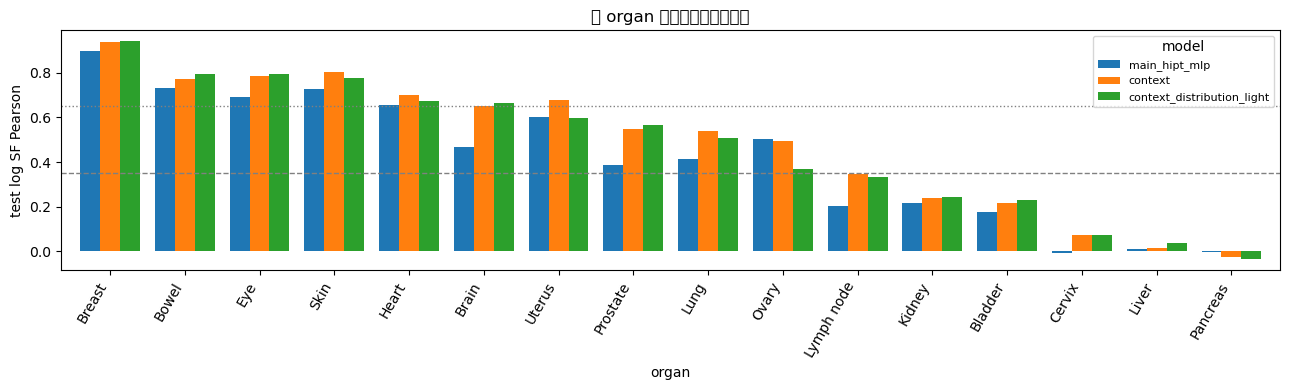

In [7]:
pivot_corr = organ_comparison.pivot_table(
    index="organ",
    columns="model",
    values="log_sf_pearson",
    aggfunc="first",
)
pivot_corr = pivot_corr.sort_values(best_model, ascending=False)
display(pivot_corr.round(4))

ax = pivot_corr[["main_hipt_mlp", "context", "context_distribution_light"]].plot(
    kind="bar",
    figsize=(13, 4),
    width=0.8,
)
ax.axhline(0.35, color="gray", linestyle="--", linewidth=1)
ax.axhline(0.65, color="gray", linestyle=":", linewidth=1)
ax.set_ylabel("test log SF Pearson")
ax.set_xlabel("organ")
ax.set_title("按 organ 分开的预测效果对比")
ax.legend(title="model", fontsize=8)
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

按当前候选模型 `context_distribution_light` 来看：

- **预测效果好**：Breast、Bowel、Eye、Skin、Heart、Brain。
- **中等**：Uterus、Prostate、Lung、Ovary。
- **预测效果不好**：Lymph node、Kidney、Bladder、Cervix、Liver、Pancreas。

最需要单独诊断的是 Liver、Pancreas 和 Cervix，因为它们不仅相关性低，而且高 SF 区域仍然预测不上去。Kidney 的 spot 数很多，虽然不是最差，但会明显影响整体结论，也必须单独看。